In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../DataSet/house_price.csv")
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [3]:
x_train = df[
    [
        "bedrooms",
        "bathrooms",
        "sqft_living",
        "sqft_lot",
        "floors",
        # "waterfront",
        # "view",
        # "condition",
        "sqft_above",
        "sqft_basement",
        # "yr_built",
        # "yr_renovated/",
    ]
].to_numpy()
y_train = df["price"].to_numpy().round(2)

In [4]:
#  Feature Scaling
x_mean = x_train.mean(axis=0)  # axis = 0 is mean for every feature
x_std = x_train.std(axis=0)

# Z-Score Normalization
x_train_scaled = (x_train - x_mean) / x_std

In [5]:
m = x_train.shape[0]  # no of training examples
n = x_train.shape[1]  # no of features
m, n

(4600, 7)

In [30]:
w = np.zeros(n)
b = 0.0
learning_rate = 0.01  # for z score normalized
iterations = 2000

In [24]:
def compute_output(x: np.ndarray, w: np.ndarray, b) -> np.ndarray:
    return np.dot(x, w) + b

In [25]:
def compute_cost(x: np.ndarray, y: np.ndarray, w: np.ndarray, b):
    m = x.shape[0]

    y_hat = compute_output(x, w, b)  # m x 1

    sq_error = (y_hat - y) ** 2

    cost = np.sum(sq_error) / (2 * m)

    return cost

In [26]:
def compute_gradient(x: np.ndarray, y: np.ndarray, w: np.ndarray, b):
    m = x.shape[0]

    y_hat = compute_output(x, w, b)

    error = y_hat - y

    dj_dw = np.dot(x.T, error) / m
    dj_db = np.sum(error) / m

    return dj_dw, dj_db

In [27]:
def gradient_descent(
    x: np.ndarray, y: np.ndarray, w_init: np.ndarray, b_init, alpha, iterations
):
    w = w_init.copy()
    b = b_init

    m = x.shape[0]
    n = x.shape[1]

    cost_history = []

    for i in range(iterations):

        dj_dw, dj_db = compute_gradient(x, y, w, b)

        w -= alpha * dj_dw
        b -= alpha * dj_db

        cost = compute_cost(x, y, w, b)
        cost_history.append(cost)

        if i % 100 == 0:
            print(f"Iteration {i}, Cost: {cost}")

    return w, b, cost_history

In [28]:
w_final, b_final, cost_hist = gradient_descent(
    x_train_scaled, y_train, w, b, learning_rate, iterations
)

Iteration 0, Cost: 297376887886.09326
Iteration 100, Cost: 128998812859.34117
Iteration 200, Cost: 128305837760.33711
Iteration 300, Cost: 128267300709.49353
Iteration 400, Cost: 128261697565.97957
Iteration 500, Cost: 128260650167.96652
Iteration 600, Cost: 128260433947.07635
Iteration 700, Cost: 128260387725.96837
Iteration 800, Cost: 128260377730.45998
Iteration 900, Cost: 128260375560.7088
Iteration 1000, Cost: 128260375089.13399
Iteration 1100, Cost: 128260374986.60033
Iteration 1200, Cost: 128260374964.30363
Iteration 1300, Cost: 128260374959.4549
Iteration 1400, Cost: 128260374958.40044
Iteration 1500, Cost: 128260374958.17108
Iteration 1600, Cost: 128260374958.12125
Iteration 1700, Cost: 128260374958.11038
Iteration 1800, Cost: 128260374958.10808
Iteration 1900, Cost: 128260374958.1075


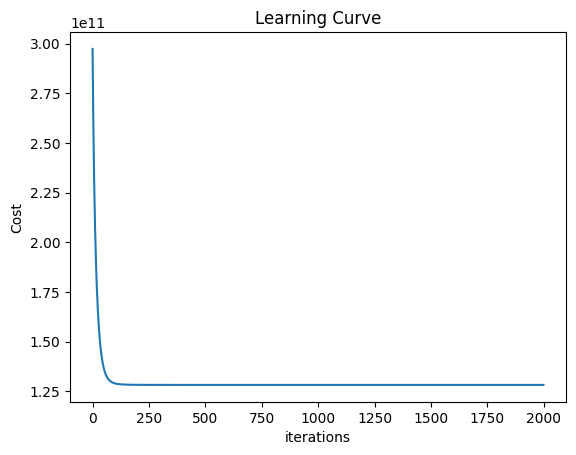

In [ ]:
plt.plot(cost_hist)
plt.title("Learning Curve")
plt.xlabel("iterations")
plt.ylabel("Cost")
plt.show()

In [20]:
print(f"Final parameters:\n w = {w_final}\nb = {b_final}")

Final parameters:
 w = [-53579.96234248   7605.12492468 138557.67736403 -24949.75998304
   4848.48663863 112406.52343133  78740.28099475]
b = 551962.9874408407


In [22]:
bedrooms = float(input("Bedrooms: "))
bathrooms = float(input("Bathrooms: "))
sqft_living = float(input("Sqft Living: "))
sqft_lot = float(input("Sqft Lot: "))
floors = float(input("Floors: "))
# waterfront = float(input("Waterfront (0 or 1): "))
# view = float(input("View Rating: "))
# condition = float(input("Condition Rating: "))
sqft_above = float(input("Sqft Above: "))
sqft_basement = float(input("Sqft Basement: "))
# yr_built = float(input("Year Built: "))
# yr_renovated = float(input("Year Renovated (0 if none): "))

# creating feature vector
x_user = np.array(
    [
        bedrooms,
        bathrooms,
        sqft_living,
        sqft_lot,
        floors,
        # waterfront,
        # view,
        # condition,
        sqft_above,
        sqft_basement,
        # yr_built,
        # yr_renovated,
    ]
)

x_user_scaled = (x_user - x_mean) / x_std

# prediction
predicted_price = compute_output(x_user_scaled, w_final, b_final)

print(f"\nPredicted House Price: ${predicted_price:,.2f}")


Predicted House Price: $470,950.31
